# This notebook is for surveillance path generation verion 7
# The AABB was developed by JJJ.
# The objective of this notebook is to develop Multiple-OBB algorithm to generate the surveillance path.

In [36]:
import numpy as np
from matplotlib.path import Path
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Tuple, Optional, Union, Dict

@dataclass
class MinOnlyBounds:
    wmin: float = 10.0; hmin: float = 10.0

def _obs_to_open_mask(nx:int, ny:int, obs_pos:List[int]) -> np.ndarray:
    open_mask = np.ones((ny, nx), dtype=bool)  # True=open, False=obstacle
    for idx in obs_pos:
        r, c = divmod(idx, nx)
        open_mask[r, c] = False
    return open_mask

def _auto_min_spacing(open_mask: np.ndarray, k: int) -> int:
    """오픈셀 면적과 점 개수로부터 대략적인 격자 최소 간격 추정."""
    open_cells = int(open_mask.sum())
    if k <= 1 or open_cells <= 1:
        return 1
    # 한 점이 차지하는 평균 면적의 루트 ≈ 간격
    spacing = int(np.sqrt(open_cells / k))
    return max(2, spacing)

def _farthest_point_sampling(open_mask: np.ndarray,
                             k: int,
                             min_spacing: Optional[int] = None,
                             seed: int = 7) -> List[Tuple[int,int]]:
    """오픈셀에서 farthest-point 방식으로 k개 샘플링 (격자 간격 제한 지원)."""
    ys, xs = np.where(open_mask)
    N = len(ys)
    if N == 0 or k <= 0:
        return []
    rng = np.random.default_rng(seed)

    if min_spacing is None:
        min_spacing = _auto_min_spacing(open_mask, k)

    pts = np.stack([ys, xs], axis=1)  # (N,2)
    # 시작점: 랜덤
    i0 = int(rng.integers(0, N))
    anchors = [tuple(pts[i0])]
    # 각 후보에 대해 "현재 선택된 앵커까지의 최소 제곱거리" 유지
    d2 = np.sum((pts - pts[i0])**2, axis=1)

    # helper: 간격 제약 검사
    def _ok_spacing(p, anchors_list, ms=min_spacing):
        py, px = p
        for (ay, ax) in anchors_list:
            if (py - ay)**2 + (px - ax)**2 < ms**2:
                return False
        return True

    # 루프: 가장 먼 점을 고르되, 간격 불만족이면 후보 제외 → 반복
    while len(anchors) < k:
        j = int(np.argmax(d2))
        if d2[j] < 0:  # 더 이상 유효 후보 없음
            break
        cand = tuple(pts[j])
        if _ok_spacing(cand, anchors):
            anchors.append(cand)
            # 거리 업데이트(최소 거리 유지)
            d2 = np.minimum(d2, np.sum((pts - pts[j])**2, axis=1))
        else:
            # 간격 불만족: 해당 후보 영구 제외
            d2[j] = -1.0

        # 후보가 모두 소진되면 간격을 조금씩 완화
        if (d2 > 0).sum() == 0 and len(anchors) < k:
            min_spacing = max(1, min_spacing - 1)
            # 간격 완화 후 거리배열 초기화/갱신
            d2[:] = np.inf
            for (ay, ax) in anchors:
                d2 = np.minimum(d2, np.sum((pts - np.array([ay, ax]))**2, axis=1))
            # 이미 간격 위반으로 제외했던 것들도 재검토되도록 음수는 0으로 리셋
            d2[d2 < 0] = 0.0

    return anchors[:k]

def sample_anchors_in_open_space(nx:int, ny:int, obs_pos:List[int],
                                 num_avs:int,
                                 min_spacing: Optional[int] = None,
                                 seed:int = 7) -> List[Tuple[int,int]]:
    """
    오픈 공간에서 num_avs개의 anchor를 골고루 분산시켜 반환.
    - min_spacing: 격자 단위 최소 간격(없으면 자동 추정)
    - 반환 형식: [(row, col), ...]
    """
    open_mask = _obs_to_open_mask(nx, ny, obs_pos)
    anchors = _farthest_point_sampling(open_mask, num_avs, min_spacing=min_spacing, seed=seed)
    return anchors

def plot_anchors(nx:int, ny:int, obs_pos:List[int], anchors:List[Tuple[int,int]], title:str="Anchors"):
    grid = np.ones((ny, nx), dtype=float)
    for idx in obs_pos:
        r, c = divmod(idx, nx)
        grid[r, c] = 0.0

    plt.figure(figsize=(6,6))
    plt.imshow(grid, cmap='RdYlBu', origin='lower', vmin=0, vmax=1, alpha=0.85)
    if anchors:
        ay = [a[0] for a in anchors]
        ax = [a[1] for a in anchors]
        plt.scatter(ax, ay, s=60, marker='o', edgecolors='k')
        for i, (r,c) in enumerate(anchors, 1):
            plt.text(c, r, str(i), ha='center', va='center', fontweight='bold')
    plt.xticks([]); plt.yticks([])
    plt.title(title)
    plt.show()

def generate_region(shape: str,
                    nx: int = 20,
                    ny: int = 20,
                    **kwargs) -> Tuple[int, int, List[int]]:
    """
    Generate a grid region and return (nx, ny, obs_pos).
    Shapes:
      - "rectangle": central open rectangle; rest are obstacles
          kwargs: rect_w (int), rect_h (int), margin_x (int), margin_y (int)
      - "l": L-shaped open area; rest obstacles
          kwargs: vx0,vx1,vy0,vy1 (vertical leg), hx0,hx1,hy0,hy1 (horizontal leg)
      - "y": Y-shaped open area; rest obstacles
          kwargs: cx, cy (center), stem_h, arm_len, arm_thick, stem_thick, slope (float)
      - "random": random organic open blob via drunkard walk
          kwargs: steps (int), seeds (int), jitter_prob (float), seed (int)
    """
    shape = shape.lower()
    open_mask = np.zeros((ny, nx), dtype=bool)  # False = obstacle, True = open

    if shape == "rectangle":
        rect_w  = kwargs.get("rect_w", max(4, nx // 2))
        rect_h  = kwargs.get("rect_h", max(4, ny // 2))
        margin_x = kwargs.get("margin_x", (nx - rect_w) // 2)
        margin_y = kwargs.get("margin_y", (ny - rect_h) // 2)
        x0 = np.clip(margin_x, 0, nx-1); y0 = np.clip(margin_y, 0, ny-1)
        x1 = np.clip(x0 + rect_w - 1, 0, nx-1)
        y1 = np.clip(y0 + rect_h - 1, 0, ny-1)
        open_mask[y0:y1+1, x0:x1+1] = True

    elif shape == "l":
        # Defaults tuned to create a clear 'L' in 20x15~25x25 grids
        vx0 = kwargs.get("vx0", 3);  vx1 = kwargs.get("vx1", 8)
        vy0 = kwargs.get("vy0", 3);  vy1 = kwargs.get("vy1", max(12, ny//2+4))
        hx0 = kwargs.get("hx0", vx1); hx1 = kwargs.get("hx1", min(nx-3, vx1+9))
        hy0 = kwargs.get("hy0", vy1-3); hy1 = kwargs.get("hy1", vy1)
        # Clip and paint vertical + horizontal legs
        vx0, vx1 = sorted([np.clip(vx0,0,nx-1), np.clip(vx1,0,nx-1)])
        vy0, vy1 = sorted([np.clip(vy0,0,ny-1), np.clip(vy1,0,ny-1)])
        hx0, hx1 = sorted([np.clip(hx0,0,nx-1), np.clip(hx1,0,nx-1)])
        hy0, hy1 = sorted([np.clip(hy0,0,ny-1), np.clip(hy1,0,ny-1)])
        open_mask[vy0:vy1+1, vx0:vx1+1] = True
        open_mask[hy0:hy1+1, hx0:hx1+1] = True

    elif shape == "y":
        # Y with one stem upward and two arms down-left / down-right
        cx = kwargs.get("cx", nx//2); cy = kwargs.get("cy", ny//2)
        stem_h = kwargs.get("stem_h", max(8, ny//3))
        stem_thick = kwargs.get("stem_thick", max(2, nx//12))
        arm_len = kwargs.get("arm_len", max(6, nx//3))
        arm_thick = kwargs.get("arm_thick", max(2, nx//14))
        slope = kwargs.get("slope", 0.6)

        yy, xx = np.mgrid[0:ny, 0:nx]
        # Vertical stem (upwards from center)
        stem = (np.abs(xx - cx) <= stem_thick//2) & (yy >= cy) & (yy <= min(ny-1, cy + stem_h))
        # Two arms (down-left and down-right)
        armL = (yy <= cy + 2) & (yy >= max(0, cy - arm_len)) & (np.abs((yy - cy) + slope*(xx - cx)) <= arm_thick)
        armR = (yy <= cy + 2) & (yy >= max(0, cy - arm_len)) & (np.abs((yy - cy) - slope*(xx - cx)) <= arm_thick)
        open_mask |= stem | armL | armR

    elif shape == "random":
        # Drunkard-walk style blob(s) for a connected-ish open region
        steps = kwargs.get("steps", nx * ny // 2)
        seeds = kwargs.get("seeds", 2)
        jitter_prob = kwargs.get("jitter_prob", 0.15)
        seed = kwargs.get("seed", 7)
        rng = np.random.default_rng(seed)

        # Start seeds near center
        centers = np.clip(np.array([
            [ny//2 + rng.integers(-ny//6, ny//6), nx//2 + rng.integers(-nx//6, nx//6)]
            for _ in range(seeds)
        ]), [0,0], [ny-1, nx-1])

        for (sy, sx) in centers:
            y, x = int(sy), int(sx)
            open_mask[y, x] = True
            for _ in range(steps // seeds):
                # Move with a small bias to keep it compact
                dy, dx = rng.choice([-1, 0, 1]), rng.choice([-1, 0, 1])
                if rng.random() < jitter_prob:
                    dy = rng.choice([-1, 1]); dx = rng.choice([-1, 1])
                y = int(np.clip(y + dy, 0, ny-1))
                x = int(np.clip(x + dx, 0, nx-1))
                open_mask[y, x] = True
                # Occasionally thicken locally
                if rng.random() < 0.2:
                    y0, y1 = max(0, y-1), min(ny-1, y+1)
                    x0, x1 = max(0, x-1), min(nx-1, x+1)
                    open_mask[y0:y1+1, x0:x1+1] = True
    else:
        raise ValueError(f"Unknown shape: {shape}. Use one of: rectangle, l, y, random")

    # Convert to obs_pos (row-major indices for obstacles = where open_mask is False)
    obs_pos: List[int] = [int(r * nx + c) for r in range(ny) for c in range(nx) if not open_mask[r, c]]
    return nx, ny, obs_pos


In [37]:
Number = Union[int, float]

def _broadcast_param(x: Union[Number, List[Number]], k: int) -> List[Number]:
    """스칼라 -> 길이 k 리스트 브로드캐스트."""
    if isinstance(x, (int, float)):
        return [x] * k
    assert len(x) == k, f"Length mismatch: expected {k}, got {len(x)}"
    return list(x)

def _rect_cover_mask(nx:int, ny:int, rect:Dict[str, float]) -> np.ndarray:
    """
    단일 회전 사각형에 의해 커버되는 셀(센터포인트 기준) 마스크 반환 (True=커버).
    rect: {'x0','y0','w','h','theta_deg'}, x0/y0는 좌측하단 기준점.
    """
    x0, y0, w, h, th = rect["x0"], rect["y0"], rect["w"], rect["h"], rect["theta_deg"]
    # 셀 중심 좌표 (x: 0.5..nx-0.5, y: 0.5..ny-0.5)
    xs = np.arange(nx) + 0.5
    ys = np.arange(ny) + 0.5
    X, Y = np.meshgrid(xs, ys)  # shape (ny, nx)

    # 앵커 기준 좌표로 이동 후, -theta 회전(직교 정렬로 투영)
    rad = np.deg2rad(th)
    ct, st = np.cos(rad), np.sin(rad)
    Xp = X - x0
    Yp = Y - y0
    # inverse rotate by theta: [x'; y'] = R(-theta) [Xp; Yp]
    Xr =  ct * Xp + st * Yp
    Yr = -st * Xp + ct * Yp

    inside = (Xr >= 0.0) & (Xr <= w) & (Yr >= 0.0) & (Yr <= h)
    return inside

def coverage_ratio_open_space(
    nx:int, ny:int, obs_pos:List[int], bboxes:List[Dict[str, float]]
) -> Tuple[float, np.ndarray]:
    """
    박스 합집합이 오픈 스페이스에서 커버하는 비율(0~1) 반환.
    - 커버 판정은 셀 중심점이 박스 내부에 있는지로 계산.
    - 장애물 셀은 분모에서 제외.
    반환: (ratio, covered_union_mask)  # covered_union_mask는 전체 그리드 기준
    """
    open_mask = _obs_to_open_mask(nx, ny, obs_pos)
    if open_mask.sum() == 0:
        return 0.0, np.zeros_like(open_mask, dtype=bool)

    union_mask = np.zeros_like(open_mask, dtype=bool)
    for rect in bboxes:
        union_mask |= _rect_cover_mask(nx, ny, rect)

    covered_open = (union_mask & open_mask).sum()
    ratio = covered_open / float(open_mask.sum())
    return ratio, union_mask

# --- (optional) quick viewer for rotated bboxes ---
def plot_rotated_bboxes(nx:int, ny:int, obs_pos:List[int], bboxes:List[Dict[str, float]], title:str=""):
    grid = np.ones((ny, nx), dtype=float)
    for idx in obs_pos:
        r, c = divmod(idx, nx)
        grid[r, c] = 0.0

    fig, ax = plt.subplots(figsize=(6,6))
    ax.imshow(grid, cmap='RdYlBu', origin='lower', vmin=0, vmax=1, alpha=0.85)
    for i, rect in enumerate(bboxes, 1):
        x0, y0, w, h, th = rect["x0"], rect["y0"], rect["w"], rect["h"], rect["theta_deg"]
        patch = Rectangle((x0, y0), w, h, angle=th, fill=False, linewidth=2)
        ax.add_patch(patch)
        # 라벨은 중심 근사치(회전 반영 없이 w/2,h/2)로 배치
        ax.text(x0 + w*0.5, y0 + h*0.5, str(i), ha='center', va='center', fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    if title: ax.set_title(title)
    plt.show()


def build_bboxes_from_anchors_ll(
    anchors: List[Tuple[int,int]],
    widths: Union[Number, List[Number]],
    heights: Union[Number, List[Number]],
    thetas_deg: Union[Number, List[Number]]
) -> List[Dict[str, float]]:
    """
    앵커(행,열)를 박스의 '좌측하단(lower-left)' 코너로 놓고 회전 사각형 정의.
    좌표계: x=열(col), y=행(row), y는 아래에서 위로 증가(plt.imshow(origin='lower')와 일치)
      - anchor = (r, c) -> (x0, y0) = (c, r)
      - width: +x 방향, height: +y 방향
      - theta_deg: CCW(+), anchor(좌측하단) 기준 회전
    반환: [{'x0','y0','w','h','theta_deg'}, ...]
    """
    k = len(anchors)
    W = _broadcast_param(widths, k)
    H = _broadcast_param(heights, k)
    T = _broadcast_param(thetas_deg, k)
    bboxes = []
    for (r, c), w, h, t in zip(anchors, W, H, T):
        bboxes.append({"x0": float(c), "y0": float(r), "w": float(w), "h": float(h), "theta_deg": float(t)})
    return bboxes

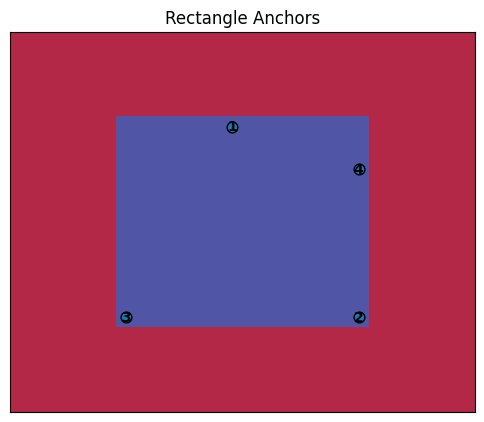

Coverage ratio on open space = 0.925


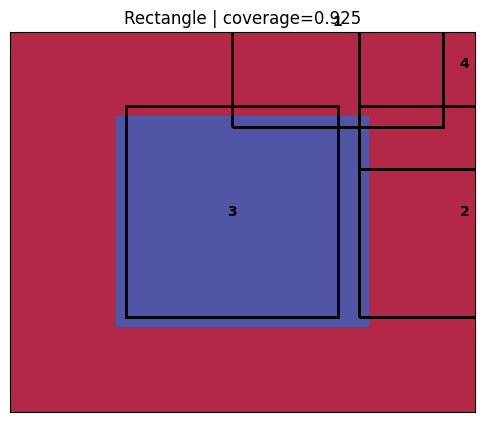

In [ ]:

# --- (Optional) quick preview: uncomment to see all four shapes ---
if __name__ == "__main__":

    # Make area
    shapes = [("rectangle", dict(nx=100, ny=100, rect_w=80, rect_h=80)),
              ("l",         dict(nx=22, ny=16)),
              ("y",         dict(nx=25, ny=25)),
              ("random",    dict(nx=24, ny=20, steps=200, seeds=2, seed=13))]
       
    # Parameter setting
    # TODO : FOV, line space part are required
    # TODO : MinOnlyBounds should be calculated from the area size and altitude
    # TODO : 'thetas' varibale should be expaned according to the 'num_avs'
    # TODO : box_size could set to be same because to consider a fair share.
    thetas = 0
    num_avs = 4
    altitude = 500  # altitude
    bounds= MinOnlyBounds(10,10)  # Bbox minimum size constraints
    target_shape = "rectangle"
    time_limit = 10 # seconds
    for name, kw in shapes:
        if name == target_shape:
            nx, ny, obs_pos = generate_region(name, **kw)
            anchors = sample_anchors_in_open_space(nx, ny, obs_pos, num_avs=num_avs, min_spacing=None, seed=7)
            plot_anchors(nx, ny, obs_pos, anchors, f"{name.capitalize()} Anchors")

            bboxes = build_bboxes_from_anchors_ll(anchors, widths=bounds.wmin, heights=bounds.hmin, thetas_deg=thetas)
            ratio, union_mask = coverage_ratio_open_space(nx, ny, obs_pos, bboxes)

            print(f"Coverage ratio on open space = {ratio:.3f}")
            plot_rotated_bboxes(nx, ny, obs_pos, bboxes, f"{name.capitalize()} | coverage={ratio:.3f}")
            break
